In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import torch

### Create file with labels

In [2]:
import csv

data_dir='coil-20-proc'
filenames = [name for name in os.listdir(data_dir) if os.path.splitext(name)[-1] == '.png']
labels=[]
for i, filename in enumerate(filenames):
    labels.append([filename,filename.split('obj')[-1].split('_')[0]])

with open('coil-20-proc/labels.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerows(labels)

### Loading the dataset

In [3]:
from torchvision.io import decode_image
from torch.utils.data import Dataset

class ImgDataset(Dataset):
    def __init__(self, annotations_file, img_dir):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image=decode_image(img_path)
        image=image.float() / 255.0
        label = self.img_labels.iloc[idx, 1]

        return image, label

In [4]:
data = ImgDataset(
    img_dir="coil-20-proc",
    annotations_file="coil-20-proc/labels.csv"
)

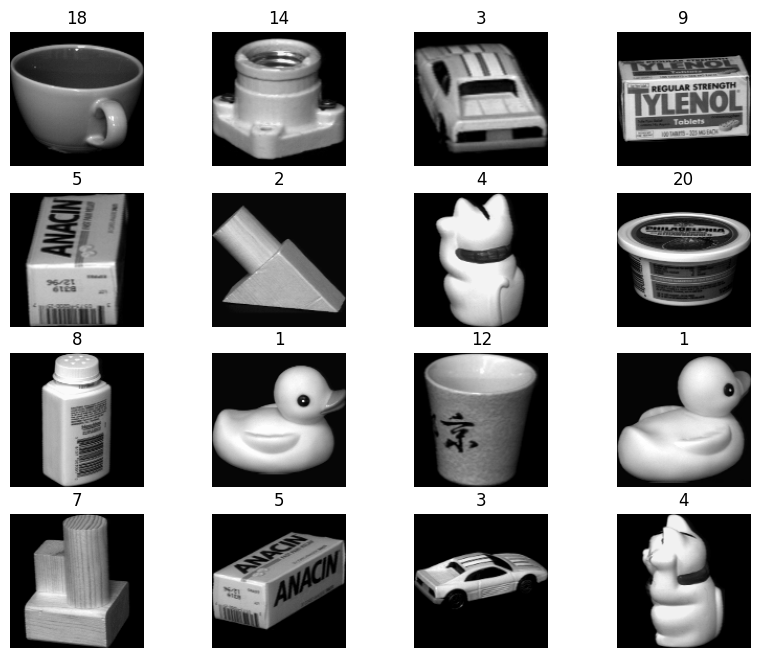

In [5]:
figure = plt.figure(figsize=(10, 8))
cols, rows = 4, 4
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(data), size=(1,)).item()
    img, label = data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [6]:
from torch.utils.data import random_split
from torch.utils.data import DataLoader

n_total = len(data)
n_train = int(0.8* n_total)
n_val = int(0.1 * n_total)
n_test = n_total - n_train - n_val

train_dataset, val_dataset, test_dataset = random_split(data, [n_train, n_val, n_test])

batch_size = 32

loaders = {
    'train' : torch.utils.data.DataLoader(train_dataset,batch_size=batch_size,shuffle=True),
    'validation'  : torch.utils.data.DataLoader(val_dataset,batch_size=batch_size),
    'test'  : torch.utils.data.DataLoader(test_dataset, batch_size = batch_size)
}

In [7]:
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_nn = nn.Sequential(
        nn.Conv2d(in_channels=1,out_channels=16,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2),
        nn.Flatten(),
        nn.Linear(16*64*64,20)
        )

    def forward(self,x):
        return self.conv_nn(x)
    
    
model_cnn  = CNN()
print(model_cnn)

CNN(
  (conv_nn): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Flatten(start_dim=1, end_dim=-1)
    (4): Linear(in_features=65536, out_features=20, bias=True)
  )
)


In [8]:
loss_f = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=0.01)

def train(num_epochs, model, loaders):
    for epoch in range(num_epochs):
        epoch_train_loss = 0
        model.train()
        for i, (images, labels) in enumerate(loaders['train']):
            output = model(images)
            labels=labels-1
            loss = loss_f(output, labels)
            epoch_train_loss += loss.item()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # Validate the model
        epoch_val_loss = 0
        model.eval()
        for images_v, labels_v in loaders['validation']:
            output = model(images_v)
            labels_v=labels_v-1
            loss_v = loss_f(output, labels_v)
            epoch_val_loss += loss_v.item()

        print(f'Epoch {epoch+1}')
        print(f'Training Loss:  %.5f' % (epoch_train_loss / len(loaders["train"].dataset)))
        print(f'Validation Loss: %.5f' % (epoch_val_loss / len(loaders["validation"].dataset)))
        print('-------------------')


In [9]:
train(5,model_cnn,loaders)

Epoch 1
Training Loss:  0.20180
Validation Loss: 0.00866
-------------------
Epoch 2
Training Loss:  0.00239
Validation Loss: 0.00129
-------------------
Epoch 3
Training Loss:  0.00020
Validation Loss: 0.00071
-------------------
Epoch 4
Training Loss:  0.00005
Validation Loss: 0.00091
-------------------
Epoch 5
Training Loss:  0.00003
Validation Loss: 0.00082
-------------------


In [10]:
def evaluate(model, test_loader):
    model.eval()
    correct = 0
    for test_imgs, test_labels in test_loader:
        output = model(test_imgs)
        predicted = torch.max(output,1)[1]
        test_labels=test_labels-1
        correct += (predicted == test_labels).sum()
    print(f'Test accuracy: %.3f' % (float(correct) / len(test_loader.dataset)))

In [11]:
evaluate(model_cnn,loaders['test'])

Test accuracy: 1.000


Accuracy 1.0 indicates that the model is overfitting. Most likely due to data leakage.

The dataset contains 72 images per object taken at pose interval of 5 degrees. 
Object rotated by 5 degrees looks almost the same as before the rotation. If two nearly identical images end up in both training and test sets, model memorizes images from the training dataset instead of learning to generalize.